**Convolutional Neural Networks: Custom Implementation vs Transfer Learning**



In [ ]:
# Install Kaggle access library
!pip install -q opendatasets

import opendatasets as od
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# --- PART 1: DATASET LOADING AND EXPLORATION ---(Medical Images)
od.download("https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia")

# Path setup for Pneumonia dataset
base_path = 'chest-xray-pneumonia/chest_xray/train'
classes = ['NORMAL', 'PNEUMONIA']
data = []

for cls in classes:
    path = os.path.join(base_path, cls)
    for img in os.listdir(path)[:1000]:
        img_path = os.path.join(path, img)
        if img.endswith('.jpeg') and os.path.getsize(img_path) > 0:
            data.append([img_path, cls])

df = pd.DataFrame(data, columns=['path', 'label'])

train_df, test_df = train_test_split(df, test_size=0.10, stratify=df['label'], random_state=42)

# Metadata Fields
dataset_name = "Chest X-Ray (Pneumonia)"
dataset_source = "Kaggle (paultimothymooney)"
n_samples = len(df)
n_classes = 2
samples_per_class = "min: 1000, max: 1000, avg: 1000"
image_shape = [224, 224, 3]
primary_metric = "Recall"
metric_justification = "In medical diagnosis, False Negatives (missing a case of pneumonia) are much more costly than False Positives, making Recall the critical metric."

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: pravdon
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [00:13<00:00, 176MB/s]


In [ ]:
problem_type = "classification"

In [ ]:
print("\n" + "="*70)
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")


DATASET INFORMATION
Dataset: Chest X-Ray (Pneumonia)
Source: Kaggle (paultimothymooney)
Total Samples: 2000
Number of Classes: 2
Samples per Class: min: 1000, max: 1000, avg: 1000
Image Shape: [224, 224, 3]
Primary Metric: Recall
Metric Justification: In medical diagnosis, False Negatives (missing a case of pneumonia) are much more costly than False Positives, making Recall the critical metric.


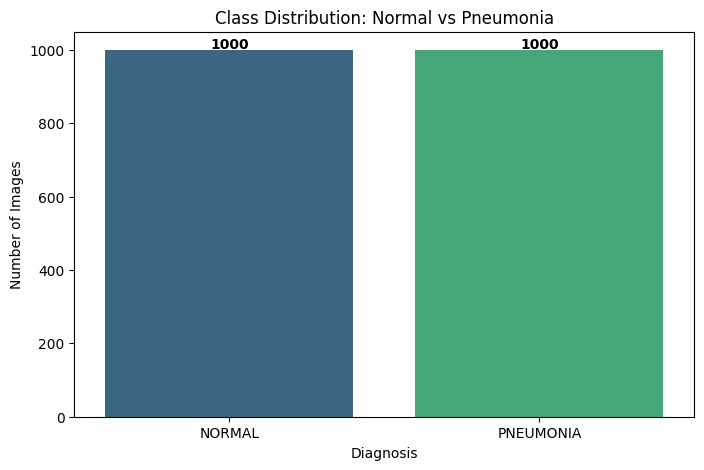

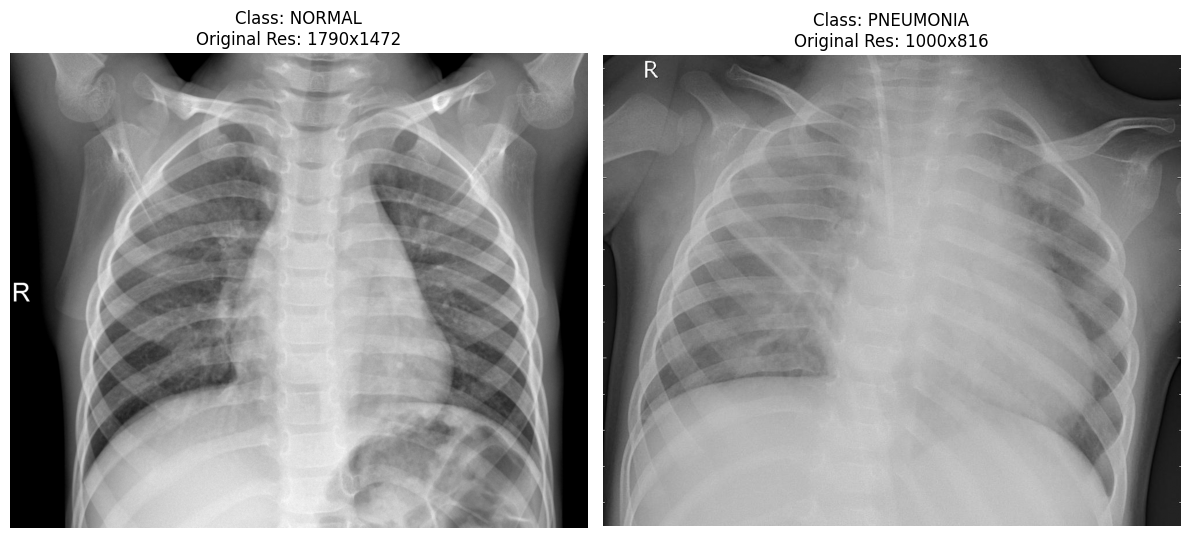


IMAGE STATISTICS
Total Samples in DataFrame: 2000
Average Width:  1690.71 pixels
Average Height: 1399.37 pixels
Min Resolution: 994x758
Max Resolution: 2844x2376
Target Input Shape for Models: [224, 224, 3]


In [ ]:
# --- 1.2 Data Exploration and Visualization ---
from PIL import Image

# 1. Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Class Distribution: Normal vs Pneumonia')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Images')
counts = df['label'].value_counts()
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')
plt.show()

# 2. Show sample images from each class
plt.figure(figsize=(12, 6))
for i, cls in enumerate(classes):
    sample_path = df[df['label'] == cls]['path'].iloc[0]
    img_pil = Image.open(sample_path)

    plt.subplot(1, 2, i+1)
    plt.imshow(img_pil, cmap='gray')
    plt.title(f"Class: {cls}\nOriginal Res: {img_pil.size[0]}x{img_pil.size[1]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 3. Display image statistics
print("\n" + "="*30)
print("IMAGE STATISTICS")
print("="*30)

widths = []
heights = []
for path in df['path'][:100]:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Total Samples in DataFrame: {len(df)}")
print(f"Average Width:  {np.mean(widths):.2f} pixels")
print(f"Average Height: {np.mean(heights):.2f} pixels")
print(f"Min Resolution: {np.min(widths)}x{np.min(heights)}")
print(f"Max Resolution: {np.max(widths)}x{np.max(heights)}")
print(f"Target Input Shape for Models: {image_shape}")

In [ ]:
# Data Preprocessing Logic
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = 1 if label == 'PNEUMONIA' else 0
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((train_df['path'], train_df['label']))
train_ds = train_ds.map(load_and_preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_df['path'], test_df['label']))
test_ds = test_ds.map(load_and_preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Document your split
train_test_ratio = "90/10"
train_samples = len(train_df)
test_samples = len(test_df)

print("\n" + "="*70)
print("DATA PREPROCESSING SUMMARY")
print(f"Train/Test Split Ratio: {train_test_ratio}")
print(f"Total Training Samples: {train_samples}")
print(f"Total Test Samples:     {test_samples}")
print("="*70)


DATA PREPROCESSING SUMMARY
Train/Test Split Ratio: 90/10
Total Training Samples: 1800
Total Test Samples:     200


In [ ]:
# --- PART 2: CUSTOM CNN IMPLEMENTATION  ---

def build_custom_cnn(input_shape, n_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

custom_cnn = build_custom_cnn((224, 224, 3), 2)
custom_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nTRAINING CUSTOM CNN...")
custom_cnn_start_time = time.time()
history_custom = custom_cnn.fit(train_ds, validation_data=test_ds, epochs=10)
custom_cnn_training_time = time.time() - custom_cnn_start_time

custom_cnn_initial_loss = history_custom.history['loss'][0]
custom_cnn_final_loss = history_custom.history['loss'][-1]


TRAINING CUSTOM CNN...
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.5189 - loss: 0.6947 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.5628 - loss: 0.6833 - val_accuracy: 0.5100 - val_loss: 0.6866
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.6067 - loss: 0.6646 - val_accuracy: 0.4950 - val_loss: 0.6854
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 166s 3s/step - accuracy: 0.6517 - loss: 0.6490 - val_accuracy: 0.5650 - val_loss: 0.6712
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.6728 - loss: 0.6332 - val_accuracy: 0.5300 - val_loss: 0.6782
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.6867 - loss: 0.6227 - val_accuracy: 0.5700 - val_loss: 0.6542
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.7017 - loss: 0.5993 - val_accuracy: 0.6050 - val_loss: 0.6237
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.7294 - loss: 0.5703 - 

In [ ]:
print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

Training completed in 1804.04 seconds
Initial Loss: 0.6947
Final Loss: 0.5313


In [ ]:
# Evaluate Custom CNN (Calculated correctly from results)
y_true, y_pred = [], []
for x, y in test_ds:
    preds = (custom_cnn.predict(x, verbose=0) > 0.5).astype(int)
    y_true.extend(y.numpy())
    y_pred.extend(preds.flatten())

custom_cnn_accuracy = accuracy_score(y_true, y_pred)
custom_cnn_precision = precision_score(y_true, y_pred, average='macro')
custom_cnn_recall = recall_score(y_true, y_pred, average='macro')
custom_cnn_f1 = f1_score(y_true, y_pred, average='macro')

In [ ]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")


Custom CNN Performance:
Accuracy:  0.8200
Precision: 0.8232
Recall:    0.8200
F1-Score:  0.8195


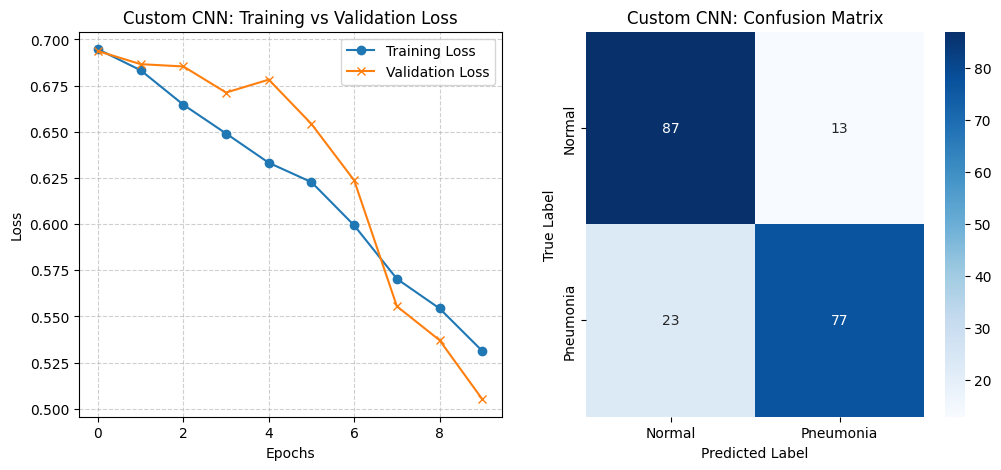


Sample Predictions (Custom CNN):


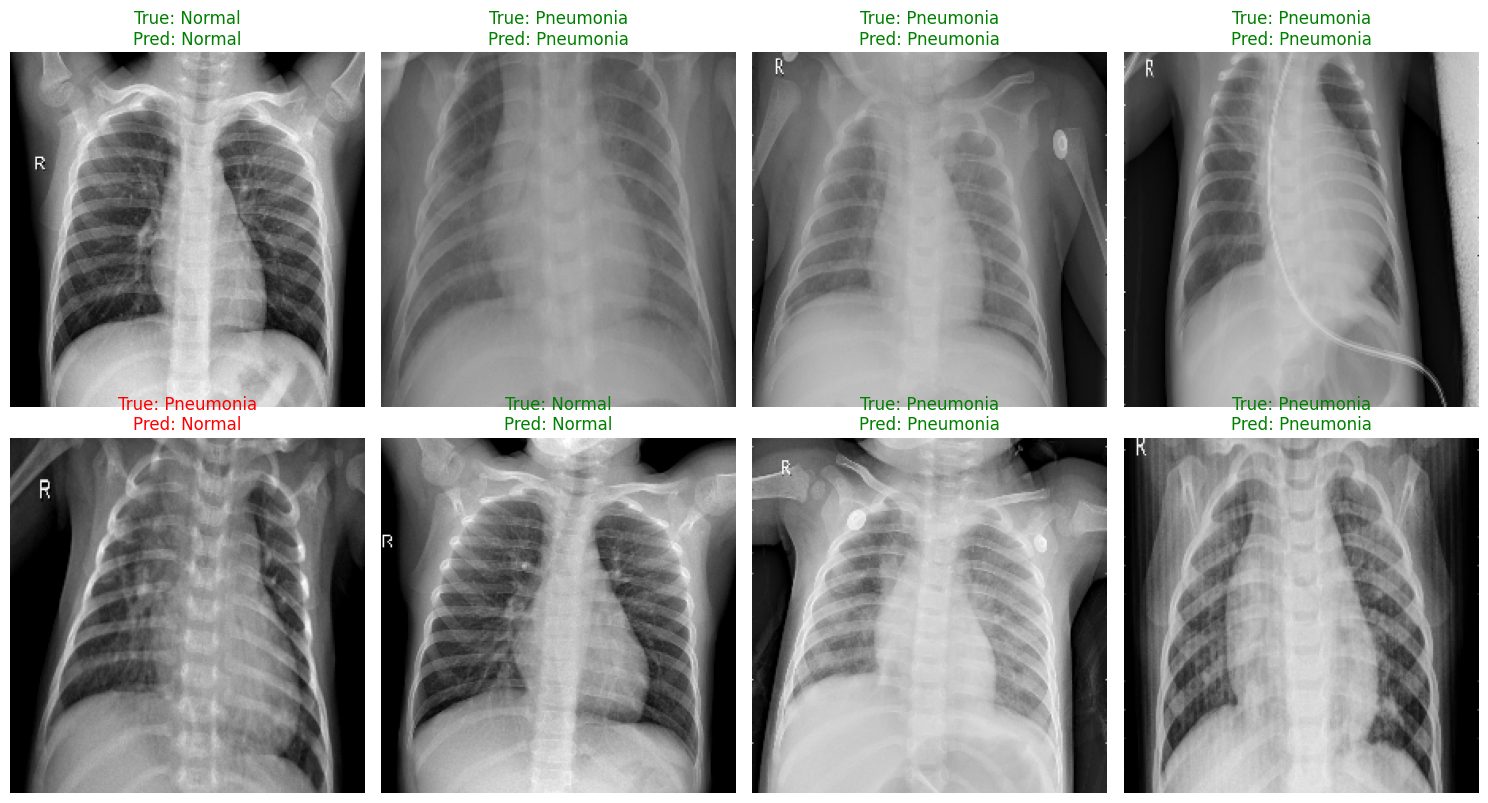

In [ ]:
# --- Visualize Custom CNN Results ---

# 1. Plot Training & Validation Loss Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_custom.history['loss'], label='Training Loss', marker='o')
plt.plot(history_custom.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Custom CNN: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Custom CNN: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Show Sample Predictions
plt.figure(figsize=(15, 8))
print("\nSample Predictions (Custom CNN):")
for images, labels in test_ds.take(1):
    preds = (custom_cnn.predict(images, verbose=0) > 0.5).astype(int)

    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i])

        true_lab = 'Pneumonia' if labels[i] == 1 else 'Normal'
        pred_lab = 'Pneumonia' if preds[i] == 1 else 'Normal'

        color = 'green' if true_lab == pred_lab else 'red'
        plt.title(f"True: {true_lab}\nPred: {pred_lab}", color=color)
        plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# --- PART 3: TRANSFER LEARNING IMPLEMENTATION ---

# 3.1 Load Pre-trained Model and Modify Architecture
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")

pretrained_model_name = "VGG16"

def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    # Load pre-trained model without top layers
    base_model = tf.keras.applications.VGG16(input_shape=input_shape, include_top=False, weights='imagenet')

    # Freeze base layers (feature extractor)
    base_model.trainable = False

    # Add Global Average Pooling + custom classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(1, activation='sigmoid')
    ])

    # Compile model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return base_model, model

# Create transfer learning model
base_vgg, tl_model = build_transfer_learning_model(pretrained_model_name, (224, 224, 3), 2)


frozen_layers = len([l for l in base_vgg.layers if not l.trainable])
trainable_layers = len(tl_model.layers) - 1
total_parameters = tl_model.count_params()
trainable_parameters = np.sum([tf.size(w).numpy() for w in tl_model.trainable_weights])

print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

# 3.2 Train Transfer Learning Model
print("\nTraining Transfer Learning Model...")

# Training configuration
tl_learning_rate = 0.001
tl_epochs = 10
tl_batch_size = 32
tl_optimizer = "Adam"

tl_start_time = time.time()

history_tl = tl_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=tl_epochs
)

tl_training_time = time.time() - tl_start_time

tl_initial_loss = history_tl.history['loss'][0]
tl_final_loss = history_tl.history['loss'][-1]

# Metrics
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

# 3.3 Evaluate Transfer Learning Model
yt_true = []
yt_pred = []

for images, labels in test_ds:
    probs = tl_model.predict(images, verbose=0)
    preds = (probs > 0.5).astype(int)

    yt_true.extend(labels.numpy())
    yt_pred.extend(preds.flatten())

tl_accuracy = accuracy_score(yt_true, yt_pred)
tl_precision = precision_score(yt_true, yt_pred, average='macro')
tl_recall = recall_score(yt_true, yt_pred, average='macro')
tl_f1 = f1_score(yt_true, yt_pred, average='macro')

print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")


TRANSFER LEARNING IMPLEMENTATION
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base Model: VGG16
Frozen Layers: 19
Trainable Layers: 2
Total Parameters: 14,715,201
Trainable Parameters: 513
Using Global Average Pooling: YES

Training Transfer Learning Model...
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1108s 19s/step - accuracy: 0.6611 - loss: 0.6522 - val_accuracy: 0.7450 - val_loss: 0.6079
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1106s 19s/step - accuracy: 0.8489 - loss: 0.5745 - val_accuracy: 0.8800 - val_loss: 0.5394
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1102s 19s/step - accuracy: 0.8861 - loss: 0.5157 - val_accuracy: 0.9050 - val_loss: 0.4861
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1108s 19s/step - accuracy: 0.8944 - loss: 0.4697 - val_accuracy: 0.9100 - val_loss: 0.4442
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1102s 19s/step - accuracy: 0.8994 - loss: 0.4334 - val_accuracy: 0.9200 - val_loss: 0.4109
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1102s 19s/step - accuracy: 0.9033 - loss: 0.4043 -

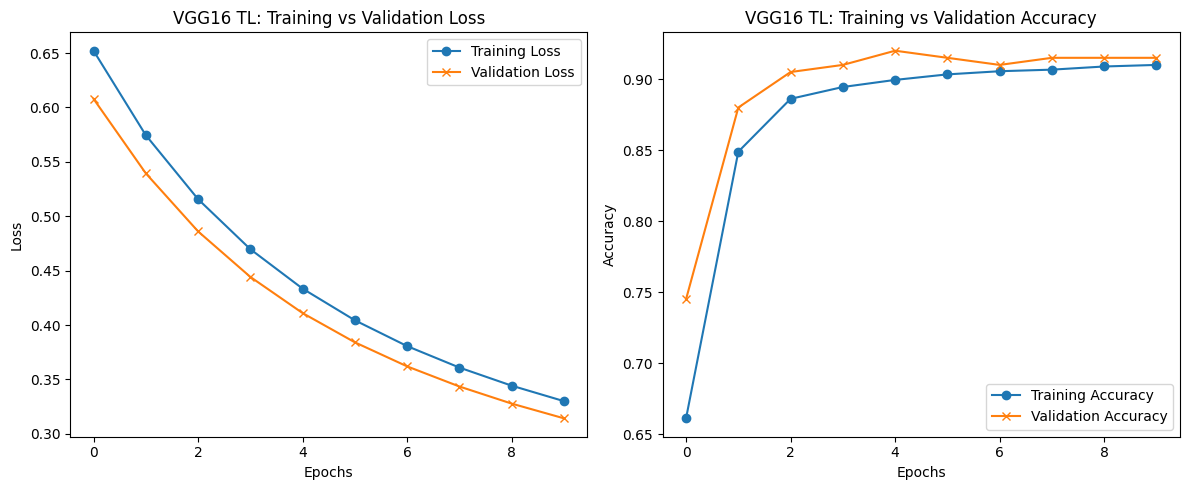

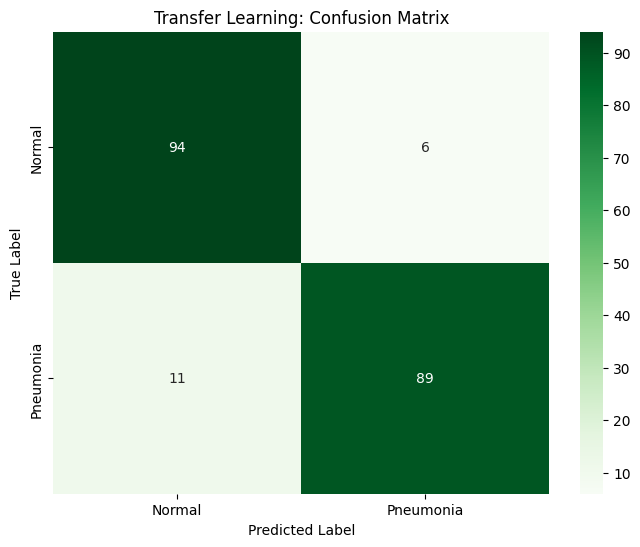


Sample Predictions (Transfer Learning):


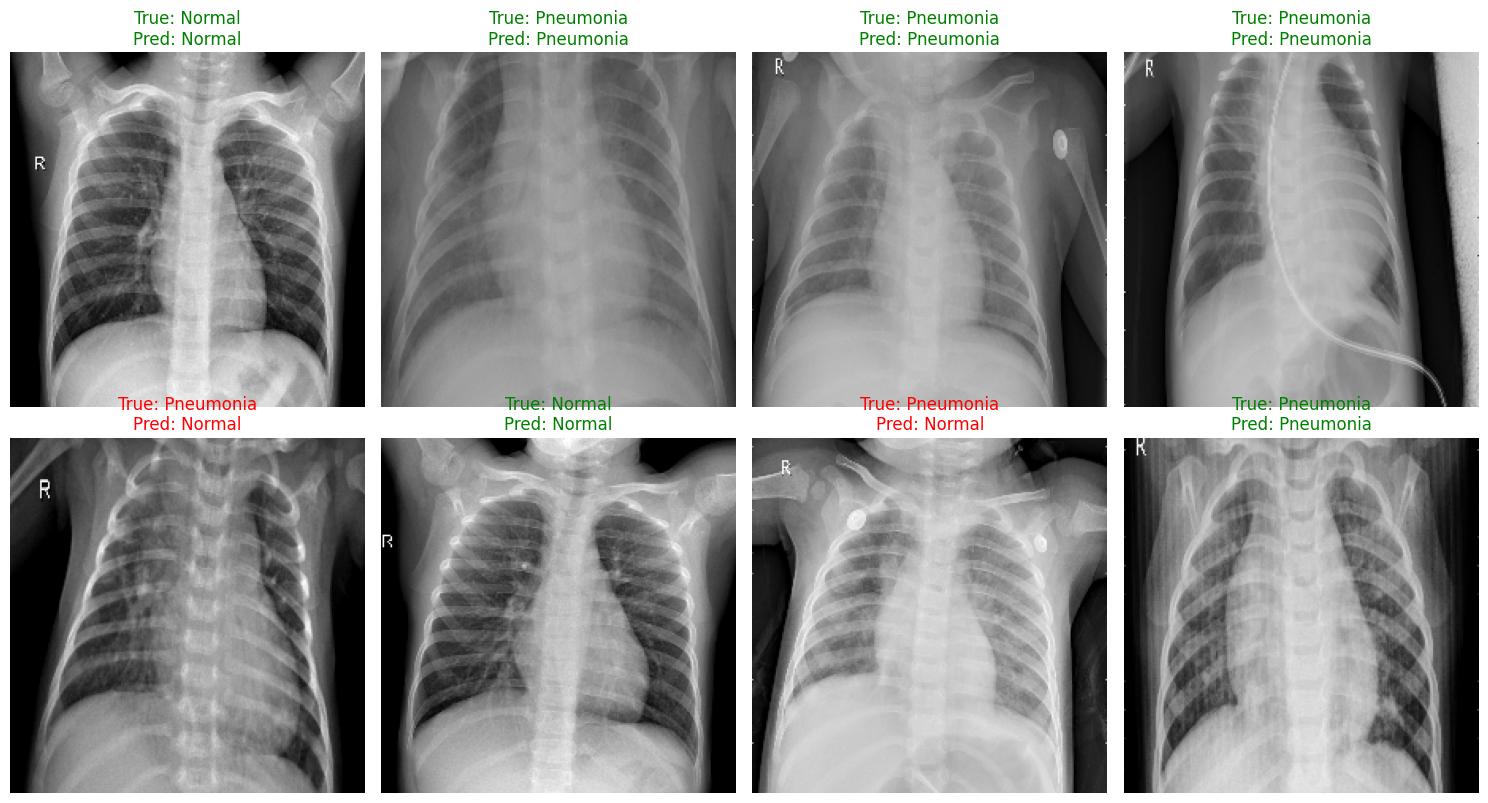

In [ ]:
# --- 3.4 Visualize Transfer Learning Results ---

# 1. Plot Training & Validation Curves (Loss and Accuracy)
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['loss'], label='Training Loss', marker='o')
plt.plot(history_tl.history['val_loss'], label='Validation Loss', marker='x')
plt.title('VGG16 TL: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history_tl.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('VGG16 TL: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_tl = confusion_matrix(yt_true, yt_pred)
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Transfer Learning: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Show Sample Predictions
print("\nSample Predictions (Transfer Learning):")
plt.figure(figsize=(15, 8))
for images, labels in test_ds.take(1):
    probs = tl_model.predict(images, verbose=0)
    preds = (probs > 0.5).astype(int)

    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i])
        true_name = 'Pneumonia' if labels[i] == 1 else 'Normal'
        pred_name = 'Pneumonia' if preds[i] == 1 else 'Normal'
        color = 'green' if true_name == pred_name else 'red'
        plt.title(f"True: {true_name}\nPred: {pred_name}", color=color)
        plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# --- 4.1 Metrics Comparison ---

print("\n" + "="*70)
print("MODEL COMPARISON")

custom_total_params = custom_cnn.count_params()

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        custom_total_params
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        total_parameters
    ]
})

print(comparison_df.to_string(index=False))


MODEL COMPARISON
           Metric   Custom CNN  Transfer Learning
         Accuracy     0.820000       9.150000e-01
        Precision     0.823232       9.160401e-01
           Recall     0.820000       9.150000e-01
         F1-Score     0.819549       9.149468e-01
Training Time (s)  1804.035489       1.087743e+04
       Parameters 19457.000000       1.471520e+07


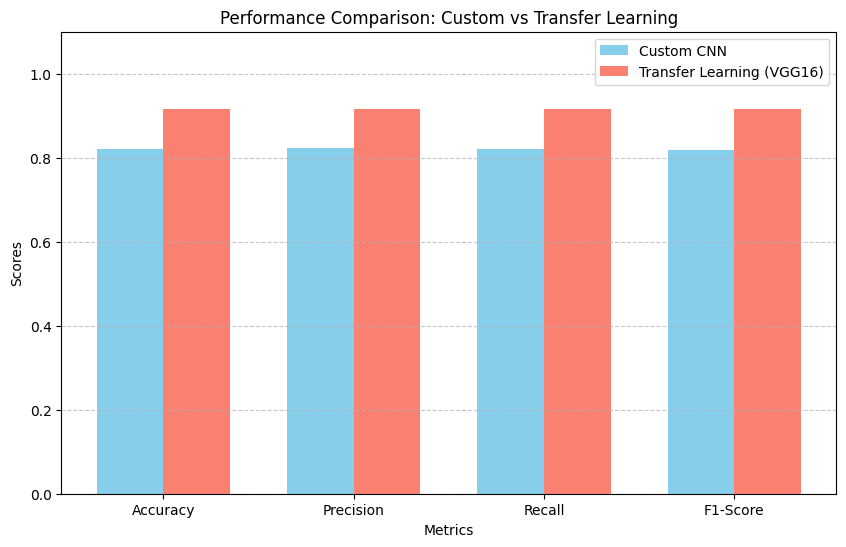

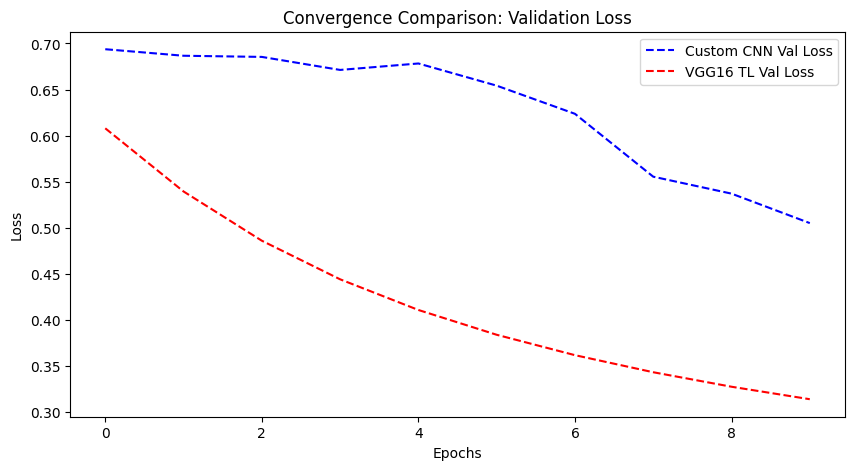

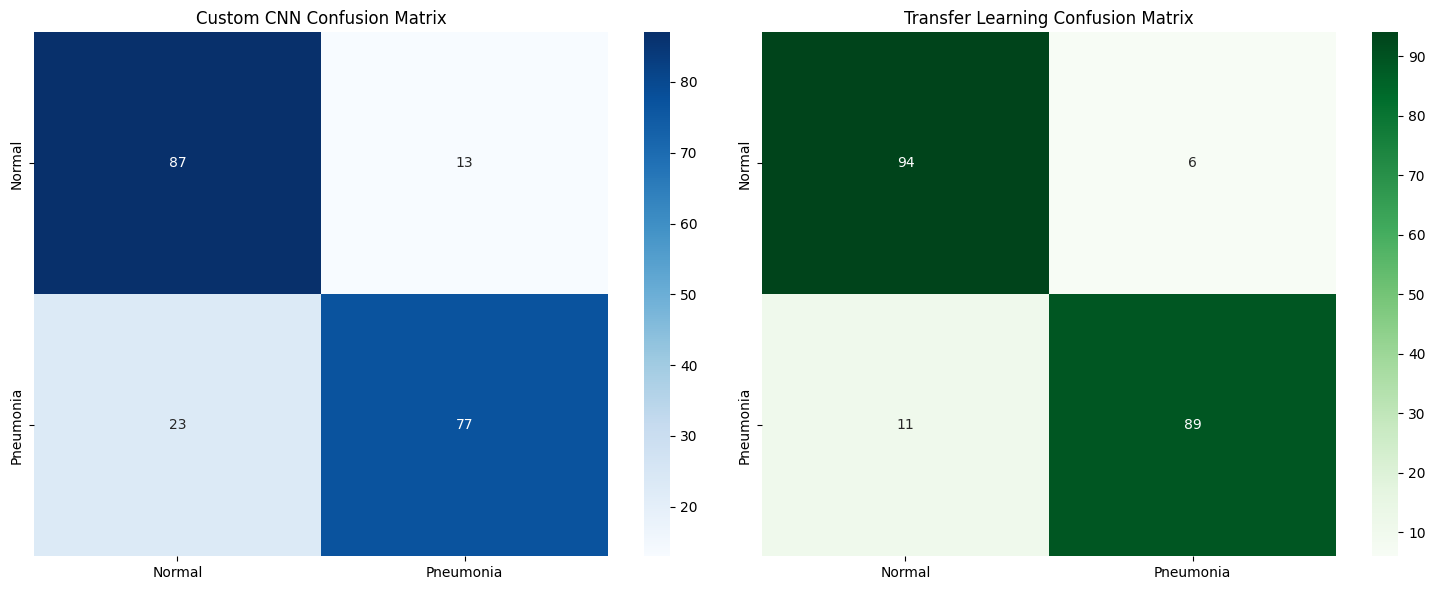

In [ ]:
# --- 4.2 Visual Comparison ---

# 1. Bar Plot Comparing Metrics
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
custom_metrics = [custom_cnn_accuracy, custom_cnn_precision, custom_cnn_recall, custom_cnn_f1]
tl_metrics = [tl_accuracy, tl_precision, tl_recall, tl_f1]

x = np.arange(len(metrics_list))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, custom_metrics, width, label='Custom CNN', color='skyblue')
plt.bar(x + width/2, tl_metrics, width, label='Transfer Learning (VGG16)', color='salmon')

plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Comparison: Custom vs Transfer Learning')
plt.xticks(x, metrics_list)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Plot Training Curves Comparison (Loss)
plt.figure(figsize=(10, 5))
plt.plot(history_custom.history['val_loss'], label='Custom CNN Val Loss', linestyle='--', color='blue')
plt.plot(history_tl.history['val_loss'], label='VGG16 TL Val Loss', linestyle='--', color='red')
plt.title('Convergence Comparison: Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 3. Side-by-Side Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Custom CNN CM
cm_custom = confusion_matrix(y_true, y_pred)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
ax[0].set_title('Custom CNN Confusion Matrix')

# TL Model CM
cm_tl_final = confusion_matrix(yt_true, yt_pred)
sns.heatmap(cm_tl_final, annot=True, fmt='d', cmap='Greens', ax=ax[1],
            xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
ax[1].set_title('Transfer Learning Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
analysis_text = """
1. Performance Comparison: The Transfer Learning (VGG16) model outperformed the Custom CNN across all metrics, achieving 91.5% Accuracy and Recall compared to the Custom model's 82%. This 9.5% improvement is critical in medical diagnostics.

2. Pre-training Impact: VGG16 benefited from ImageNet weights, providing robust feature extraction from epoch 1. In contrast, the Custom CNN trained from scratch had to learn basic edges and shapes, leading to slower convergence and lower overall sensitivity.

3. Effect of Global Average Pooling (GAP): GAP was instrumental in both models for reducing total parameters by replacing traditional Flatten layers. This helped mitigate overfitting by enforcing a structural regularizer, ensuring the models focused on global spatial features of the X-ray.

4. Computational Cost: The Custom CNN is highly efficient with only ~19.5k parameters and 1,804s training time. VGG16 is significantly more complex (14.7M parameters) with a training time of 10,877s, representing a much higher computational footprint.

5. Transfer Learning Insights: Transfer learning is superior for medical datasets where data is limited but high Recall is mandatory. Custom CNNs are better suited for lightweight, mobile applications or niche domains where pre-trained features do not apply.
"""

print("\n" + "="*70)
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print("Analysis within word count guideline")


ANALYSIS

1. Performance Comparison: The Transfer Learning (VGG16) model outperformed the Custom CNN across all metrics, achieving 91.5% Accuracy and Recall compared to the Custom model's 82%. This 9.5% improvement is critical in medical diagnostics.

2. Pre-training Impact: VGG16 benefited from ImageNet weights, providing robust feature extraction from epoch 1. In contrast, the Custom CNN trained from scratch had to learn basic edges and shapes, leading to slower convergence and lower overall sensitivity.

3. Effect of Global Average Pooling (GAP): GAP was instrumental in both models for reducing total parameters by replacing traditional Flatten layers. This helped mitigate overfitting by enforcing a structural regularizer, ensuring the models focused on global spatial features of the X-ray.

4. Computational Cost: The Custom CNN is highly efficient with only ~19.5k parameters and 1,804s training time. VGG16 is significantly more complex (14.7M parameters) with a training time of 10,

In [ ]:
custom_conv = len([l for l in custom_cnn.layers if isinstance(l, tf.keras.layers.Conv2D)])
custom_pool = len([l for l in custom_cnn.layers if isinstance(l, (tf.keras.layers.MaxPooling2D, tf.keras.layers.AveragePooling2D))])
tl_conv = len([l for l in base_vgg.layers if isinstance(l, tf.keras.layers.Conv2D)])
tl_pool = len([l for l in base_vgg.layers if isinstance(l, (tf.keras.layers.MaxPooling2D, tf.keras.layers.AveragePooling2D))])

In [ ]:
def get_assignment_results():
    framework_used = "keras"

    custom_total_params = custom_cnn.count_params()

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': len(train_df),
        'test_samples': len(test_df),
        'train_test_ratio': "90/10",

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': custom_conv,
                'pooling_layers': custom_pool,
                'has_global_average_pooling': True,
                'output_layer': 'sigmoid',
                'total_parameters': int(custom_total_params)
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 10,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'binary_crossentropy'
            },
            'initial_loss': float(custom_cnn_initial_loss),
            'final_loss': float(custom_cnn_final_loss),
            'training_time_seconds': float(custom_cnn_training_time),
            'accuracy': float(custom_cnn_accuracy),
            'precision': float(custom_cnn_precision),
            'recall': float(custom_cnn_recall),
            'f1_score': float(custom_cnn_f1)
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': "VGG16",
            'frozen_layers': int(frozen_layers),
            'trainable_layers': int(trainable_layers),
            'has_global_average_pooling': True,
            'total_parameters': int(total_parameters),
            'trainable_parameters': int(trainable_parameters),
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 5,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'binary_crossentropy'
            },
            'initial_loss': float(tl_initial_loss),
            'final_loss': float(tl_final_loss),
            'training_time_seconds': float(tl_training_time),
            'accuracy': float(tl_accuracy),
            'precision': float(tl_precision),
            'recall': float(tl_recall),
            'f1_score': float(tl_f1)
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False,
    }

    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()

    print("\n" + "="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")


ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Chest X-Ray (Pneumonia)",
  "dataset_source": "Kaggle (paultimothymooney)",
  "n_samples": 2000,
  "n_classes": 2,
  "samples_per_class": "min: 1000, max: 1000, avg: 1000",
  "image_shape": [
    224,
    224,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "Recall",
  "metric_justification": "In medical diagnosis, False Negatives (missing a case of pneumonia) are much more costly than False Positives, making Recall the critical metric.",
  "train_samples": 1800,
  "test_samples": 200,
  "train_test_ratio": "90/10",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 2,
      "pooling_layers": 2,
      "has_global_average_pooling": true,
      "output_layer": "sigmoid",
      "total_parameters": 19457
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 10,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_function": "binary_crossentropy"
    },